In [1]:
from panco.descriptor.curves import TokenBucket, RateLatency, sum_ac
from panco.descriptor.flow import Flow
from panco.descriptor.server import Server
from panco.descriptor.network import Network
from panco.fifoCplex.admTFA import AdmTfaCpx
from panco.fifoCplex.fifoLP import FifoLPCpx
from panco.fifoCplex.sfaLP import SfaLPCpx
import matplotlib.pyplot as plt

import time
import numpy as np

The propose of this notebook is to compute the performance bounds for the 31 networks that are freely available in [1] (testbed for paper [2]), and compare performance (both worst-case delay upper bounds and runtime) of those in the paper vs the linear-based methods. 

We try to detail as much as possible pour approach. 

[1] https://github.com/alexscheffler/dataset-rtns2022

[2] Alexander Scheffler, Jens B. Schmitt, Steffen Bondorf: Searching for Upper Delay Bounds in FIFO Multiplexing Feedforward Networks. RTNS 2022: 230-241

## Adaptation of the dataset to the Panco framework

Each network is described by a javafile `random_ff_nn.java` where `nn` is the number  of the network (from  1 to 34 with missing numbers. There are 31 networks in total. 



In [2]:
tab_num = [1, 2 , 3, 5, 6, 7, 8, 9] + list(range(10, 22)) + [23, 24] + list(range(26, 35))
print(tab_num)

filename = "random_ff_5.java"
f= open(filename)

[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34]


In the next cell, we analyze each file to make the network: 
- for each server, when `addServer` is read, we create a new server, catch its serv1ce rate (with a minimum of one, since all flows have an arrival rate 1 (in the file, thre might be service rates lower than 1, but this means that this server is unused by any flow, so this would not change the result). 
- We then analyze the flows, and we first detect the list of servers it crosses, which defines its path. 

- We have obtain a list of service rates and paths. We are then ready to define the netowk: from [2], the latncy is 0 for each server, and the arrival curves are leaky buckets whith burst 1 and arrival rate 1. 

Doing this we have forgotten the order of the flows, that doest not really matter, sinsce we are going to compute the performance guarantees in average for each network. 

In order to avid very long running times (when `lp_solve` is used instead of `Cplex`, we can cap the size of the network, and analyze only networks of sizze at most `lim_elp`

In [3]:
lim_elp = 75
list_small = []
tab_networks = []
k = 0
for i in tab_num:
    
    filename = "random_ff_"+str(i)+".java"
    
    with open(filename) as f:
        n_s = 0
        
        tab_s = []
        tab_service_rates = []
        tab_paths = []
        cur_path = []
        for line in f:
            
            if 'addServer' in line:
                n_s += 1
                values = [token for token in line.split(' ') if not token == ""]
                
                val = [token for token in values[5].split(',')]
                v1 = (val[-1][:-2])
                tab_service_rates += [(float(v1[:-2]))]
                v = ((values[3])[2:-2])
                tab_s+=[int(v)]
            if 'servers_on_path_s.add' in line:
                val_p = [token for token in line.split(' ') if not token == ""]
                
                v2 = val_p[1][8:-1]
                cur_path += [int(v2)]
                
            if 'sg.addFlow' in line:
                
                tab_paths += [cur_path]
                cur_path = []
        
        serv_rates = [0 for _ in range(n_s)]
        #print(tab_service_rates)
        #print(tab_s)
        for j in range(n_s):
            serv_rates[tab_s[j]] = max(1, tab_service_rates[j])
        #print(serv_rates)
        servers = [Server([RateLatency(r, 0)], []) for r in serv_rates]
        if n_s < lim_elp :
            list_small += [k]
        k += 1
        flows = [Flow( [TokenBucket(1, 1)], p) for p in tab_paths]
        tab_networks+= [Network(servers, flows)]
    
print(len(list_small), list_small)

31 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


Here is the description of the smallest network `random_ff_7.java`.  Servers 2 and 3 are not crossed by any flow, and we have a service rate of 1, as explained above. 

In [4]:
print(tab_networks[4])

Flows:
      0: α(t) = min [1 + 1t]; π = [17, 1, 9]
      1: α(t) = min [1 + 1t]; π = [2, 16]
      2: α(t) = min [1 + 1t]; π = [0, 7, 4]
      3: α(t) = min [1 + 1t]; π = [0, 8, 2]
      4: α(t) = min [1 + 1t]; π = [12, 14, 11, 3, 8]
      5: α(t) = min [1 + 1t]; π = [6, 17, 1, 7, 5, 10, 15]
      6: α(t) = min [1 + 1t]; π = [14, 11, 3, 8, 2, 16]
      7: α(t) = min [1 + 1t]; π = [1, 9]
      8: α(t) = min [1 + 1t]; π = [7, 5, 10]
      9: α(t) = min [1 + 1t]; π = [0, 8, 2, 16]
     10: α(t) = min [1 + 1t]; π = [0, 8, 2, 16]
     11: α(t) = min [1 + 1t]; π = [0, 7, 5, 10]
     12: α(t) = min [1 + 1t]; π = [3, 9]
     13: α(t) = min [1 + 1t]; π = [13, 5, 10, 15]
     14: α(t) = min [1 + 1t]; π = [11, 3, 8, 2]
     15: α(t) = min [1 + 1t]; π = [1, 9]
     16: α(t) = min [1 + 1t]; π = [14, 11]
     17: α(t) = min [1 + 1t]; π = [11, 3, 8]
     18: α(t) = min [1 + 1t]; π = [1, 7, 5, 10]
     19: α(t) = min [1 + 1t]; π = [12, 14, 11, 3, 9]
     20: α(t) = min [1 + 1t]; π = [14, 11, 3]
     

## Starting the evaluation. 

There are different steps fo the analysis of feed-forward networks. 
 - We first need to reorder the servers of the network with `network.make_feed_forward`, that simply change the numbering so that servers are orderedd in a topologic order (from sources to destination). 
 - then more efficient analysis (but most costly regarding the running time) is to first unfold the network with `ff.unfold(j)`, for each flow (that will be in turn the flow of interest when we compute its performance upper bound). This first step can be costly, and we compute the runnung time for the unfolding. 
 - After unfolding, it may be the case that many flows (that have been cut by the operation, if the diverge from the destination) have the same path, so in order to reduce the size of the LP, we simply aggregate the flows with the same path with `unfold.aggregate_network(foi)` (for these two operations, the number of flows is modified and we keep track of the new number of the flow of interest). 

In [5]:
def analysis_network_topo_unfold(network:Network):
    ff = network.make_feed_forward
    tab_max_depth=[]
    tab_mean_depth = []
    tab_nf = []
    tab_ns = []
    for j in range(network.num_flows):
        unfold, foi = ff.unfold(j)
        agg, f = unfold.aggregate_network(foi)
        tab_nf += [agg.num_flows]
        tab_ns += [agg.num_servers]
        tab_max_depth += [max(agg.depth)]
        tab_mean_depth += [round(float(np.mean(agg.depth)), 3)]
    return tab_nf, tab_ns, tab_max_depth, tab_mean_depth

Running times to unfold all networks for all flows, per network. 

In [6]:
tab_nf = []
tab_ns = []
tab_max_depth = []
tab_mean_depth = []

for i in list_small:
    s = time.time()
    network = tab_networks[i]
    a, b, c, d= analysis_network_topo_unfold(network)
    tab_nf +=[a]
    tab_ns += [b]
    tab_max_depth += [c]
    tab_mean_depth +=[d]
    print(time.time()-s, network.num_flows, network.num_servers)

0.0015759468078613281 17 14
0.004369497299194336 33 20
0.4384932518005371 230 50
0.0007083415985107422 17 14
0.002002239227294922 27 18
0.00011205673217773438 4 6
0.40738821029663086 279 58
0.004934787750244141 47 24
2.613105297088623 443 72
0.0003514289855957031 9 10
0.09831094741821289 195 50
0.7539520263671875 253 52
0.0018877983093261719 27 18
0.016573667526245117 74 30
0.0019617080688476562 27 18
0.32906293869018555 286 60
0.29914212226867676 199 48
0.05327939987182617 141 42
0.0006437301635742188 13 12
0.00017833709716796875 6 8
0.00042819976806640625 13 12
1.4366662502288818 428 72
0.038036346435546875 103 34
15.81241250038147 442 68
10.167551279067993 448 68
0.16100215911865234 130 36
0.03448128700256348 114 38
0.03677701950073242 114 38
0.19246864318847656 244 56
0.0005924701690673828 13 12
0.025960206985473633 103 36


These are the functions to compute all dlays for all networks. 

- SFA analysis (we skip TFA, bacause it would be too pesimistic, as there is no shaping curve)
- PLP (solving with Cplex). Each flow is anallyzed as described (unfolding and aggregating)
- ELP wioth Cplex, when the number of servers is small enough.  

We keep track of the per-flow delays and running times for PLP and ELP (SFA is too fast, and analyis can be factoized to avoid a per-flow analysis). 

In [7]:
def analyse_network_sfa(network:Network):
    s = time.time()
    ff = network.make_feed_forward
    sfa = SfaLPCpx(network.make_feed_forward)
    return sfa.all_delays, time.time() - s

def analyse_network_plp_unfold(network: Network):
    s = time.time()
    ff = network.make_feed_forward
    tab_u=[]
    tab_tu=[]
    for j in range(network.num_flows):
        v=time.time()
        unfold, foi = ff.unfold(j)
        agg, f = unfold.aggregate_network(foi)
        tab_u +=[FifoLPCpx(agg, sfa=True, tfa=True).delay(f)]
        tab_tu += [time.time()-v]
        print(j,  time.time()-v, agg.num_flows, agg.num_servers)
    return(tab_u, tab_tu)

def analyse_network_elp_unfold(network: Network):
    s = time.time()
    ff = network.make_feed_forward
    tab_u=[]
    tab_tu=[]
    for j in range(network.num_flows):
        v=time.time()
        unfold, foi = ff.unfold(j)
        agg, f = unfold.aggregate_network(foi)
        tab_u +=[FifoLPCpx(agg, polynomial=False).delay(f)]
        tab_tu += [time.time()-v]
        print(j,  time.time()-v, agg.num_flows, agg.num_servers)
    return(tab_u, tab_tu)



We compute everything

In [8]:
tab_time_eplp = []
tab_time_sfa = []
tab_time_plp = []
tab_time_heu = []
tab_sfa = []
tab_plp = []
tab_eplp = []
tab_heu = []
for i in list_small:
    network = tab_networks[i]
    print(i, network.num_flows, network.num_servers)
    if network.num_servers < 21:
        print('elp')
        b_elp,t_elp = analyse_network_elp_unfold(network)
        tab_time_eplp += [t_elp]
        tab_eplp += [b_elp]
    print('plp sfa')
    b_sfa, t_sfa = analyse_network_sfa(network)
    tab_sfa += [b_sfa]
    tab_time_sfa += [t_sfa]
    
    print('plp unfold')
    b_plp, t_plp = analyse_network_plp_unfold(network)
    tab_plp += [b_plp]
    tab_time_plp +=[t_plp]
    if network.num_servers >= 21:
        tab_time_eplp += [t_plp]
        tab_eplp += [b_plp]


0 17 14
elp
0 0.009869813919067383 5 4
1 0.004911899566650391 2 2
2 0.0663919448852539 10 7
3 0.004314422607421875 2 1
4 0.0037403106689453125 1 1
5 0.07878255844116211 9 7
6 0.0043756961822509766 4 3
7 0.004616498947143555 4 2
8 0.01260685920715332 8 6
9 0.0044901371002197266 2 2
10 0.011760473251342773 7 6
11 0.004121303558349609 1 1
12 0.003926515579223633 2 2
13 0.009521484375 5 4
14 0.005057334899902344 4 2
15 0.08510541915893555 10 7
16 0.08080077171325684 9 7
plp sfa
plp unfold
0 0.021158695220947266 5 4
1 0.01911187171936035 2 2
2 0.020886659622192383 10 7
3 0.016016721725463867 2 1
4 0.018245935440063477 1 1
5 0.01962137222290039 9 7
6 0.01822972297668457 4 3
7 0.016799449920654297 4 2
8 0.019859790802001953 8 6
9 0.017870187759399414 2 2
10 0.018245458602905273 7 6
11 0.01510167121887207 1 1
12 0.024057865142822266 2 2
13 0.02112293243408203 5 4
14 0.01909780502319336 4 2
15 0.021368741989135742 10 7
16 0.02230525016784668 9 7
1 33 20
elp
0 0.32868456840515137 16 9
1 0.289752

180 0.2929525375366211 193 68
181 0.02781224250793457 6 4
182 0.1050570011138916 85 29
183 0.3320755958557129 191 63
184 0.3613107204437256 196 63
185 0.31691908836364746 192 68
186 0.3199770450592041 192 68
187 0.03129768371582031 18 7
188 0.11123156547546387 87 33
189 0.11594676971435547 85 29
190 0.12672758102416992 89 30
191 0.3267710208892822 187 61
192 0.12661099433898926 89 30
193 0.15188312530517578 93 31
194 0.025060176849365234 4 2
195 0.3275156021118164 184 62
196 0.02963876724243164 12 5
197 0.42453908920288086 193 64
198 0.04641246795654297 40 15
199 0.021527767181396484 2 1
200 0.3532075881958008 191 63
201 0.2887730598449707 187 61
202 0.33934521675109863 191 63
203 0.12444400787353516 89 30
204 0.29369401931762695 184 60
205 0.03367185592651367 17 7
206 0.3778705596923828 187 61
207 0.15375447273254395 101 35
208 0.37645697593688965 197 64
209 0.06999874114990234 65 25
210 0.09859561920166016 85 29
211 0.28229331970214844 183 62
212 0.10567164421081543 93 34
213 0.28263

136 0.3631293773651123 206 63
137 0.1683824062347412 105 32
138 0.31516075134277344 201 64
139 0.09807562828063965 93 32
140 0.4149820804595947 209 64
141 0.13405942916870117 87 27
142 0.2982211112976074 201 62
143 0.30668115615844727 200 62
144 0.1775035858154297 106 33
145 0.3605048656463623 206 63
146 0.12298822402954102 94 33
147 0.24223041534423828 105 32
148 0.325791597366333 205 63
149 0.3260800838470459 203 64
150 0.06924891471862793 65 22
151 0.11957669258117676 87 27
152 0.18671178817749023 104 33
153 0.21202421188354492 109 31
154 0.17644715309143066 106 33
155 0.2559044361114502 112 32
156 0.11223173141479492 87 27
157 0.0987250804901123 93 32
158 0.32179713249206543 201 64
159 0.4129209518432617 206 63
160 0.13690924644470215 96 34
161 0.08684492111206055 77 28
162 0.09055590629577637 76 28
163 0.1834099292755127 97 31
164 0.1670675277709961 97 31
165 0.3260667324066162 201 64
166 0.3143439292907715 201 64
167 0.14770793914794922 94 31
168 0.23879456520080566 109 31
169 0.

86 0.26027894020080566 166 53
87 0.49843430519104004 305 98
88 0.9100065231323242 456 145
89 0.5817890167236328 317 101
90 0.4052104949951172 291 93
91 0.19218134880065918 139 45
92 1.0722956657409668 458 151
93 0.16471600532531738 111 37
94 0.5159702301025391 284 91
95 0.1954963207244873 140 50
96 0.14167118072509766 110 37
97 0.4837310314178467 284 91
98 0.5551879405975342 303 97
99 0.14989948272705078 134 50
100 0.2014908790588379 139 45
101 0.9171104431152344 459 151
102 0.4679713249206543 291 93
103 0.028558731079101562 6 4
104 0.9607565402984619 461 146
105 0.4265463352203369 276 98
106 0.28737664222717285 152 46
107 0.529862642288208 316 101
108 0.2616922855377197 157 52
109 0.5369594097137451 302 97
110 0.2596466541290283 166 53
111 0.21881556510925293 157 52
112 0.9458274841308594 460 146
113 0.27828311920166016 163 49
114 0.13906049728393555 131 50
115 0.316312313079834 173 53
116 0.16597390174865723 131 45
117 1.069216012954712 461 146
118 1.078920602798462 458 151
119 0.253

356 0.5205514430999756 305 98
357 0.44983863830566406 301 98
358 0.031064987182617188 21 9
359 1.0173256397247314 461 146
360 0.44426798820495605 302 97
361 0.4371347427368164 283 91
362 0.2358994483947754 156 51
363 0.050432682037353516 43 17
364 0.3060173988342285 166 53
365 0.03786730766296387 31 12
366 0.24457979202270508 151 51
367 0.5398457050323486 306 98
368 0.27927374839782715 151 46
369 0.20530462265014648 139 45
370 0.2928645610809326 163 49
371 0.2610740661621094 151 46
372 0.2247025966644287 151 51
373 0.9240555763244629 457 145
374 0.2910645008087158 156 52
375 0.5340161323547363 301 98
376 0.16263651847839355 134 50
377 0.25347423553466797 156 52
378 0.2604050636291504 156 52
379 0.22925353050231934 151 49
380 0.08550477027893066 93 33
381 0.30043506622314453 169 52
382 0.12801432609558105 111 37
383 0.12252593040466309 125 42
384 0.22355437278747559 157 51
385 0.03517746925354004 21 9
386 0.12688612937927246 132 45
387 0.22161293029785156 139 45
388 0.14213061332702637 

...

259 0.4135730266571045 253 84
260 0.355449914932251 243 82
261 0.14131546020507812 117 39
262 0.42034435272216797 262 80
263 0.8518476486206055 421 137
264 0.02694082260131836 4 2
265 0.8084053993225098 274 83
266 25.4036922454834 1333 418
267 1.0642683506011963 432 137
268 0.6513431072235107 263 80
269 0.47809481620788574 250 78
270 10.217994213104248 1328 416
271 6.474381923675537 1174 393
272 0.649895191192627 269 81
273 3.208402156829834 757 251
274 5.320314407348633 1174 393
275 0.7623441219329834 275 83
276 0.5478482246398926 263 80
277 0.7180540561676025 274 83
278 0.07607126235961914 73 26
279 0.2758762836456299 166 56
280 38.41769504547119 1332 418
281 0.17785406112670898 149 49
282 0.027114391326904297 12 6
283 0.982952356338501 435 143
284 28.870104789733887 1325 417
285 8.278521299362183 1329 416
286 13.57542896270752 1329 416
287 0.1180410385131836 99 32
288 1.0294272899627686 500 166
289 1.350635051727295 506 169
290 0.28217172622680664 149 49
291 1.9817180633544922 756 2

88 1.6202821731567383 651 196
89 0.38553762435913086 214 66
90 2.5282511711120605 893 272
91 0.032730817794799805 5 3
92 0.05994868278503418 52 17
93 1.1347661018371582 403 123
94 0.5225679874420166 244 77
95 1.971480369567871 662 199
96 0.959298849105835 407 128
97 0.8224565982818604 383 119
98 0.030475616455078125 4 2
99 0.47094249725341797 246 76
100 2.0018973350524902 651 196
101 0.26865315437316895 153 52
102 4.3944478034973145 1296 400
103 0.7246317863464355 403 125
104 0.9761524200439453 403 125
105 1.2729761600494385 407 127
106 2.380675792694092 666 199
107 0.028105497360229492 2 1
108 0.021941661834716797 2 1
109 2.0075364112854004 662 199
110 2.105471134185791 662 197
111 0.035561561584472656 14 6
112 1.0329790115356445 476 145
113 1.8674864768981934 662 199
114 0.9245033264160156 407 128
115 0.877741813659668 396 127
116 0.7013139724731445 357 113
117 0.2537729740142822 150 45
118 0.9434106349945068 408 129
119 1.1035089492797852 407 128
120 0.6294760704040527 246 75
121 0.

358 0.8098905086517334 402 125
359 1.8878140449523926 661 197
360 0.03994631767272949 7 3
361 1.0765767097473145 476 145
362 2.2093896865844727 667 199
363 0.415968656539917 213 66
364 1.1437535285949707 408 127
365 0.31787967681884766 169 52
366 0.4406161308288574 237 72
367 0.42098569869995117 237 72
368 0.9254205226898193 403 123
369 2.911393404006958 666 199
370 0.5443456172943115 243 75
371 4.766299486160278 1301 401
372 1.1373710632324219 408 129
373 2.8718457221984863 808 255
374 0.910315752029419 411 129
375 0.4468374252319336 244 75
376 4.277285814285278 1301 401
377 0.034425973892211914 12 6
378 0.024855852127075195 6 3
379 0.4888489246368408 246 76
380 0.49472880363464355 223 68
381 2.3089330196380615 661 197
382 2.4547951221466064 661 197
383 2.587928295135498 666 199
384 2.5854151248931885 891 274
385 0.9301269054412842 396 127
386 0.7554540634155273 357 113
387 0.8317921161651611 397 127
388 2.636667251586914 892 272
389 0.5352644920349121 246 76
390 0.9995977878570557 40

57 0.060028076171875 43 17
58 0.0625307559967041 43 17
59 0.023214101791381836 6 4
60 0.04865550994873047 42 16
61 0.04809999465942383 36 14
62 0.055058956146240234 36 15
63 0.03371238708496094 27 11
64 0.05837225914001465 37 15
65 0.04330849647521973 38 18
66 0.05901503562927246 42 17
67 0.04319167137145996 39 18
68 0.045125484466552734 41 19
69 0.0430142879486084 39 15
70 0.07140755653381348 43 17
71 0.05046558380126953 44 19
72 0.044226646423339844 39 19
73 0.026695966720581055 16 8
74 0.039626121520996094 38 18
75 0.04150199890136719 34 13
76 0.0341188907623291 27 11
77 0.058821678161621094 37 15
78 0.06206703186035156 37 15
79 0.027508020401000977 18 9
80 0.04174351692199707 39 15
81 0.05426788330078125 41 16
82 0.026085615158081055 15 8
83 0.0415043830871582 38 18
84 0.05183053016662598 41 16
85 0.04695868492126465 44 19
86 0.04939389228820801 45 19
87 0.041205644607543945 27 11
88 0.054491281509399414 41 19
89 0.04668068885803223 40 15
90 0.029938936233520508 17 9
91 0.024953126

110 0.14448165893554688 89 26
111 0.1163628101348877 81 27
112 0.1305375099182129 82 28
113 0.17123937606811523 80 26
114 0.20539045333862305 87 27
115 0.11257004737854004 70 28
116 0.12314748764038086 82 28
117 0.1985323429107666 87 27
118 0.0744774341583252 69 23
119 0.1296999454498291 77 25
120 0.10993576049804688 79 27
121 0.14102745056152344 81 25
122 0.024189472198486328 9 6
123 0.03828120231628418 36 15
124 0.12636804580688477 79 24
125 0.10656929016113281 70 28
126 0.1318502426147461 82 28
127 0.02659153938293457 10 6
128 0.07896971702575684 69 27
129 0.14643645286560059 81 28
130 0.15536737442016602 80 25
131 0.185866117477417 92 27
132 0.15832734107971191 79 26
133 0.12036705017089844 70 28
134 0.07890510559082031 71 23
135 0.08139634132385254 69 27
136 0.0881955623626709 68 27
137 0.14766573905944824 80 25
138 0.16750860214233398 86 26
139 0.12200498580932617 81 27
140 0.19792413711547852 93 27
141 0.07514619827270508 68 23
142 0.0503537654876709 39 14
143 0.2140481472015380

## Analysis of the results

Now, we are ready to analyse the worst-case delay bounds of the three methods. First, the avarage delay bounds with SFA, ELP, and PLP

In [10]:
tab_sfa_mean_delay = [np.mean(sfa) for sfa in tab_sfa] 

tab_plp_mean_delay = [np.mean(plp) for plp in tab_plp] 
tab_elp_mean_delay = [np.mean(eplp) for eplp in tab_eplp]

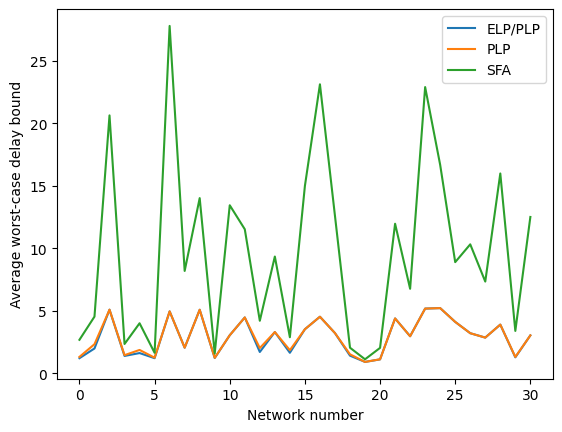

In [11]:
import matplotlib.pyplot as plt

n = len(tab_plp_mean_delay)
plt.plot(range(n), tab_elp_mean_delay, label='ELP/PLP')
plt.plot(range(n), tab_plp_mean_delay, label='PLP')
plt.plot(range(n), tab_sfa_mean_delay, label='SFA')
plt.xlabel('Network number')
plt.ylabel('Average worst-case delay bound')
plt.legend()
plt.show()

Next, the total running times for each network. 

In [12]:
tab_sfa_sum_time= [np.sum(sfa) for sfa in tab_time_sfa]
tab_plp_sum_time = [np.sum(plp) for plp in tab_time_plp] 
tab_elp_sum_time = [np.sum(elp) for elp in tab_time_eplp]

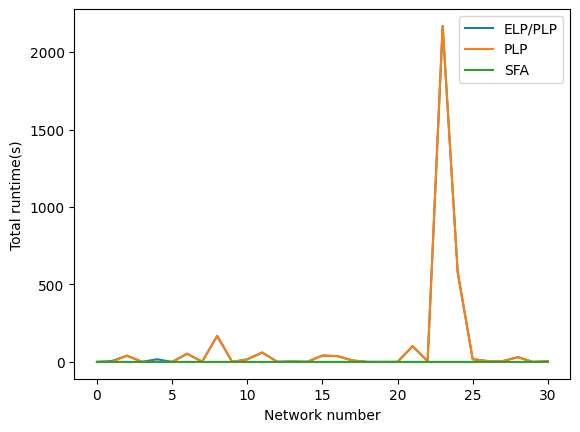

In [13]:
import matplotlib.pyplot as plt
n = len(tab_elp_mean_delay)
n1 = len(tab_plp_mean_delay)
plt.plot(range(n), tab_elp_sum_time, label="ELP/PLP")
plt.plot(range(n1), tab_plp_sum_time, label="PLP")
plt.plot(range(n1), tab_sfa_sum_time, label="SFA")
plt.xlabel('Network number')
plt.ylabel('Total runtime(s)')
plt.legend()
plt.show()

In order to compare other methods, we save the results. 

In [16]:
import pickle

with open('perf_cplex', 'wb') as file:
    pickle.dump([tab_sfa, tab_plp, tab_eplp, tab_time_sfa, tab_time_plp, tab_time_eplp], file)

In [17]:
with open('networks', 'wb') as file:
    pickle.dump(tab_networks, file)